## Day 1 – Data & Domain

### Use Case
*Focus: domain and application context*

> In the context of **financial market surveillance**, continuous-time price signals generated by the Swiss Market Index (SMI) are acquired and converted into digital form using electronic trading platforms (SIX Swiss Exchange) in order to monitor intraday volatility and assess market risk in real time.  
> The resulting digital signals are analyzed by **risk management systems and algorithmic trading platforms** to perform volatility estimation, drawdown detection, and regulatory reporting.  
> This use case is particularly relevant for **Switzerland** because the SMI is the country's most important equity benchmark, comprising the 20 largest and most liquid Swiss companies (Nestlé, Novartis, Roche, UBS, etc.), and Switzerland's financial sector contributes approximately 9% of GDP. Accurate digital representation of intraday price movements is essential for the stability of Swiss financial infrastructure.

### Problem Statement
*Focus: technical vulnerability*

> This project addresses the problem of determining an appropriate sampling rate for the **SMI closing price signal** within the context of intraday financial risk monitoring in Switzerland.  
> If the sampling rate is chosen too low, **high-frequency price fluctuations may be aliased**, causing rapid intraday movements (e.g., flash crashes, earnings-related spikes) to appear as misleading lower-frequency oscillations. This leads to **underestimated realized volatility** and missed extreme events, both of which compromise risk assessment. If the sampling rate is chosen too high, this results in excessive data volume and microstructure noise contamination, causing increased computational cost without improving the quality of volatility estimates.  
> Preserving the **spectral content of intraday price dynamics** is essential for reliable volatility estimation and risk management in this financial monitoring use case.

### Experimental Objective
*Focus: investigation goal at the conceptual level*

> The objective of this project is to examine how the choice of sampling rate affects the accuracy with which relevant intraday frequency components of the SMI price signal can be captured. The goal is to determine under which sampling conditions the signal remains sufficiently informative for reliable volatility estimation and whether undersampling leads to measurable distortion in the spectral and temporal representation of the financial time series.

### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection*

> The selected signal represents **1-minute closing price data of the Swiss Market Index (SMI)**, generated by aggregated trade executions on the SIX Swiss Exchange, measured using the electronic order book, and expressed in **CHF (Swiss Francs)**.  
> Its relevant characteristics include **broadband frequency content spanning from long-term trends (periods of hours to days) to short-term intraday fluctuations (periods of a few minutes)**, which are important for assessing both trend behavior and short-term risk.  
> The data originate from the **Yahoo Finance API** (ticker: ^SSMI), provided by Yahoo/ICE Data Services, and are appropriate because they offer publicly accessible, high-resolution intraday price data under documented market conditions for the Swiss equity market.

#### Nyquist Frequency and Nyquist Rate Interpretation

For the SMI 1-minute data:
- **Sampling interval:** T_s = 60 s → **Sampling rate:** f_s = 1/60 Hz ≈ 0.01667 Hz
- **Nyquist frequency:** f_Nyq = f_s / 2 = 1/120 Hz ≈ 0.00833 Hz
- **Minimum resolvable period:** 2 minutes

**Practical consequences of too low a sampling rate:** Price movements faster than 2× the sampling interval cannot be captured. Flash crashes occurring within seconds would be completely missed; intraday spikes lasting only a few minutes would appear distorted or averaged out. This leads to systematic underestimation of realized volatility and risk.

**Practical consequences of unnecessarily high sampling rate:** Sub-second sampling introduces microstructure noise (bid-ask bounce, tick-by-tick fluctuations) that does not reflect genuine price movements, inflating volatility estimates and increasing storage/processing costs without improving signal fidelity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.fft import fft, fftfreq

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)
if isinstance(smi_1min.columns, pd.MultiIndex):
    smi_1min.columns = smi_1min.columns.get_level_values(0)

price = smi_1min['Close'].dropna().values.astype(float)
time_index = smi_1min['Close'].dropna().index

print(f"Data points: {len(price)}")
print(f"Time span: {time_index[0]} to {time_index[-1]}")
print(f"Sampling interval: 1 minute (60 s)")
print(f"Sampling rate f_s = {1/60:.6f} Hz")
print(f"Nyquist frequency f_Nyq = {1/120:.6f} Hz")

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_9449/3634822443.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_1min = yf.download("^SSMI", period="7d", interval="1m", progress=False)


Data points: 3414
Time span: 2026-02-27 08:02:00+00:00 to 2026-03-09 14:08:00+00:00
Sampling interval: 1 minute (60 s)
Sampling rate f_s = 0.016667 Hz
Nyquist frequency f_Nyq = 0.008333 Hz


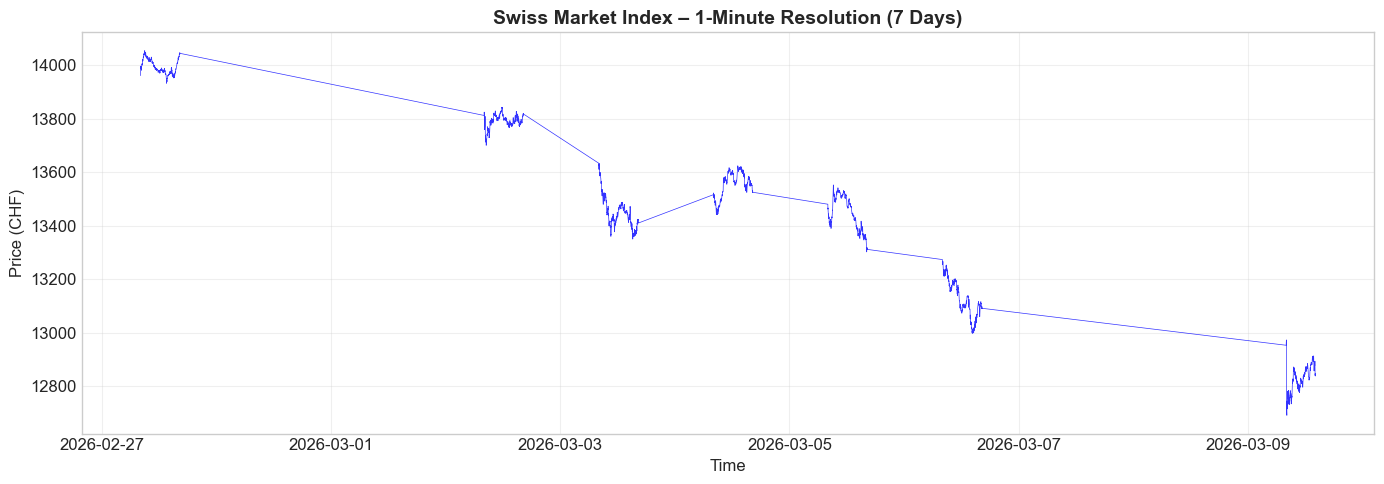

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_index, price, 'b-', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Price (CHF)', fontsize=12)
ax.set_title('Swiss Market Index – 1-Minute Resolution (7 Days)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
> The visualization illustrates the SMI intraday price dynamics over 7 trading days, with notable **short-term fluctuations superimposed on longer-term daily trends**. Gaps between trading sessions (overnight/weekend closures) are clearly visible. This signal segment was selected because it clearly highlights the broadband frequency content relevant to the defined use case: both slow trend components and rapid intraday variations that are critical for volatility estimation.